In [9]:
from notebook_setup import setup
from vizman import viz
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd

from matplotlib import font_manager
for font in font_manager.findSystemFonts("figures/Atkinson_Typeface/"):
    font_manager.fontManager.addfont(font)

viz.set_visual_style()
default_sizes = viz.load_data_from_json("sizes.json")
default_colors = viz.load_data_from_json("colors.json")
default_cmaps = viz.give_colormaps()

from kaysons_visual_config import * # Kayson's file. 

from src.visualization.find_and_plot_closest_connectome import find_closest_connectome, plot_connectome_blockwise, compare_orderings

env = setup()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Enabled autoreload.
Current path is: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/scripts


In [ ]:
experiment_name = "76_90000_samples_animal_206" 
base_path = Path("/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset") / experiment_name

data_dir = base_path / "generated_networks"
save_dir = base_path / "generated_networks_visualizations"
save_dir.mkdir(parents=True, exist_ok=True)

margin_x = 0.5
margin_y = 0.05
interesting_eta_and_gamma_combinations = [
    [-8+margin_x, 1-margin_y],  
    [3-margin_x, 1-margin_y], 
    [-0.8, 0.18],
    [3-margin_x, -0.1+margin_y], 
    [-8+margin_x, -0.1+margin_y],
    [-5, 0.5],
]

# Choose clustering method: 'spectral', 'hierarchical', 'modularity', 'degree', or None
clustering_method = 'spectral'

# Store connectomes and parameters
connectomes = []
params = []

for parameter_combination in interesting_eta_and_gamma_combinations:
    target_eta = parameter_combination[0]
    target_gamma = parameter_combination[1]
    
    found_eta, found_gamma, connectome = find_closest_connectome(target_eta, target_gamma, data_dir)
    
    connectomes.append(connectome)
    params.append((found_eta, found_gamma))
    
    parameter_combination.append(found_eta)
    parameter_combination.append(found_gamma)


Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-7.484950065612793_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (-7.5, 0.95)
Found  (η, γ): (-7.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta2.484949827194214_gamma0.948494970798492_ruleMatchingIndex_id000.npy
Target (η, γ): (2.5, 0.95)
Found  (η, γ): (2.485, 0.948)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks
Closest file found: net_eta-0.789297699928284_gamma0.179598659276962_ruleMatchingIndex_id000.npy
Target (η, γ): (-0.8, 0.18)
Found  (η, γ): (-0.789, 0.180)
Searching in: /Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/o

In [10]:
# Load the metrics data
metrics_csv_path = base_path / f"all_metrics_for_{experiment_name}.csv"
gnm_results_df = pd.read_csv(metrics_csv_path, index_col=False)

# Prepare data for MaxCriteria metric
df = gnm_results_df.copy()
df["eta"] = pd.to_numeric(df["eta"], errors='coerce')
df["gamma"] = pd.to_numeric(df["gamma"], errors='coerce')

# Find the MaxCriteria column
metric_col_name = next(col for col in df.columns if "MaxCriteria" in col)
df[metric_col_name] = pd.to_numeric(df[metric_col_name], errors='coerce')
df = df.dropna(subset=['eta', 'gamma', metric_col_name])


# BINNING
BINNING = False 
if BINNING: 
    # bin the eta and gamma values into 100 bins each
    df['eta'] = pd.cut(df['eta'], bins=100)
    df['gamma'] = pd.cut(df['gamma'], bins=100)

# PIVOTING
# Pivot the DataFrame to create a matrix for heatmap
heatmap_data = df.pivot_table(index='gamma', columns='eta', values=metric_col_name)

/Users/adrian/Documents/01_projects/14_4D_lab/14_4D_lab_code/output/gnm/suarez_MaMI_dataset/76_90000_samples_animal_206/generated_networks_visualizations/figure_1_landscape_and_connectomes.pdf


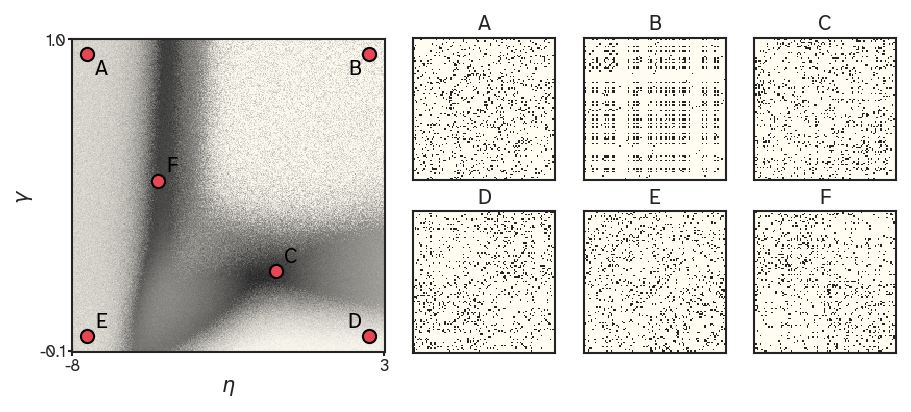

In [ ]:
point_color = "#E84653"
fig, axes = plt.subplot_mosaic(
    [["landscape", "landscape", "A", "B", "C"], 
     ["landscape", "landscape", "D", "E", "F"]], 
    figsize=(viz.cm_to_inch((18, 7))), dpi=150
    
)

# Flip the heatmap data vertically
heatmap_data_flipped = heatmap_data.iloc[::-1]

sns.heatmap(
    heatmap_data_flipped,
    square=True,    
    xticklabels=False, 
    yticklabels=False,  
    cbar=False, # True, # False,
    cmap=default_cmaps["hb_bw"],
    ax=axes["landscape"]
)

eta_values = heatmap_data_flipped.columns # np.array([interval.mid for interval in heatmap_data_flipped.columns])
gamma_values = heatmap_data_flipped.index # np.array([interval.mid for interval in heatmap_data_flipped.index])

# Set x-axis ticks (η) - only first and last
eta_min, eta_max = eta_values.min(), eta_values.max()
x_tick_positions = [0, len(eta_values) - 1]  # First and last positions
x_tick_labels = [f"{eta_min:.1f}" if eta_min % 1 != 0 else f"{int(eta_min)}", 
                 f"{eta_max:.1f}" if eta_max % 1 != 0 else f"{int(eta_max)}"]
axes["landscape"].set_xticks(x_tick_positions)
axes["landscape"].set_xticklabels(x_tick_labels)

# Set y-axis ticks (γ) - only first and last
gamma_min, gamma_max = gamma_values.min(), gamma_values.max()
y_tick_positions = [0, len(gamma_values) - 1]  # First and last positions
y_tick_labels = [f"{gamma_max:.1f}", f"{gamma_min:.1f}"]  # Note: reversed because data is flipped
axes["landscape"].set_yticks(y_tick_positions)
axes["landscape"].set_yticklabels(y_tick_labels, rotation=0)

# Set axis labels
axes["landscape"].set_xlabel(r"$\eta$") 
axes["landscape"].set_ylabel(r"$\gamma$") 

# Flip the y-axis to have low gamma at bottom
eta_values = heatmap_data_flipped.columns
gamma_values = heatmap_data_flipped.index

scatter_x = []
scatter_y = []

for combo in interesting_eta_and_gamma_combinations:
    target_eta = combo[0]
    target_gamma = combo[1]
    
    # Find closest indices in the heatmap
    x_idx = np.argmin(np.abs(eta_values - target_eta))
    y_idx = np.argmin(np.abs(gamma_values - target_gamma))
    
    scatter_x.append(x_idx)
    scatter_y.append(y_idx)

# Add scatter points to the landscape
axes["landscape"].scatter(
    scatter_x,
    scatter_y,
    color=point_color,
    s=40,
    edgecolors='black',
    linewidths=1.0,
    zorder=10,  # Ensure points are on top
    label='Selected Networks'
)

# Add text next to each point
labels = ['A', 'B', 'C', 'D', 'E', 'F']

############# FINETUNING THE SHIFTS #############
right = 14
left = 14
up = 14
down = 14

shifts = {
    'A': (right, down),
    'B': (-left, down),
    'C': (right, -up),
    'D': (-left, -up),
    'E': (right, -up),
    'F': (right, -up),
}
for x, y, label in zip(scatter_x, scatter_y, labels):
    shift_x, shift_y = shifts[label]
    axes["landscape"].text(x+shift_x, y+shift_y, f'{label}', 
            color='black', ha="center", va="center") 

# Plot connectomes
for idx, ax_label in enumerate(["A", "B", "C", "D", "E", "F"]):
    sns.heatmap(
        connectomes[idx],
        square=True,
        xticklabels=False,
        yticklabels=False,
        cbar=False,
        cmap=default_cmaps["bw_hb"],
        ax=axes[ax_label]
    )
    found_eta, found_gamma = params[idx][0], params[idx][1]
    axes[ax_label].set_title(ax_label)
        # r"$\eta$: " + f"{np.round(found_eta)}," + r"$\gamma$: " + f"{np.round(found_gamma)}")  
        
sns.despine(fig=fig, top=False, right=False, left=False, bottom=False)
#plt.tight_layout()
plt.savefig(save_dir / f"figure_1_landscape_and_connectomes.pdf", bbox_inches="tight")


print(save_dir / f"figure_1_landscape_and_connectomes.pdf")